In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
plt.rcParams['svg.fonttype'] = 'none'

C:\Users\admin\anaconda3\lib\site-packages\pandas\core\computation\expressions.py:20: UserWarning: Pandas requires version '2.7.3' or newer of 'numexpr' (version '2.7.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [5]:
mag= pd.read_csv(r'../pre-calculated_data/circular_mag.csv')
mag

,#seq_name,length,cov.,circ.,repeat,mult.,alt_group,graph_path,MAG
0,cpsnj01_contig_52172,308050,8,Y,N,1,*,52172,cpsnj01_SemiBin_85
1,cpsnj01_contig_80150,30167,6,Y,N,1,*,80150,cpsnj01_SemiBin_30
2,cpsnj01_contig_28216,23827,6,Y,N,1,*,28216,cpsnj01_SemiBin_112
3,cpsnj02_contig_9516,328497,7,Y,N,1,*,9516,cpsnj02_SemiBin_132
4,cpsnj02_contig_75066,126410,11,Y,N,1,*,75066,cpsnj02_SemiBin_1731
...,...,...,...,...,...,...,...,...,...
125,snj11_contig_33210,40218,7,Y,N,1,*,33210,snj11_SemiBin_149
126,snj13_contig_25709,407808,7,Y,N,1,*,25709,snj13_SemiBin_19
127,snj13_contig_8792,112018,12,Y,N,3,*,8792,snj13_SemiBin_84
128,snj16_contig_52328,29887,5,Y,N,1,*,52328,snj16_SemiBin_47


In [6]:
other = pd.read_csv(r'../pre-calculated_data/circular_other.csv')
other

,#seq_name,length,cov.,circ.,repeat,mult.,alt_group,graph_path,MAG
0,cpsnj01_contig_32185,124944,11,Y,N,2,*,32185,NaN
1,cpsnj01_contig_78089,93967,6,Y,N,1,*,78089,NaN
2,cpsnj01_contig_79915,90172,9,Y,N,1,*,79915,NaN
3,cpsnj01_contig_78839,83127,16,Y,N,3,*,78839,NaN
4,cpsnj01_contig_79604,75605,7,Y,N,1,*,79604,NaN
...,...,...,...,...,...,...,...,...,...
11544,snj20_contig_4573,2020,4,Y,Y,1,*,4573,NaN
11545,snj20_contig_67346,1182,29,Y,Y,7,*,67346,NaN
11546,snj20_contig_314,740,6,Y,Y,1,3078,314,NaN
11547,snj20_contig_30143,685,5,Y,Y,1,3812,30143,NaN


In [7]:
mag['Source'] = 'MAG'
other['Source'] = 'Other'
df_combined = pd.concat([mag, other], axis=0)
df_combined

,#seq_name,length,cov.,circ.,repeat,mult.,alt_group,graph_path,MAG,Source
0,cpsnj01_contig_52172,308050,8,Y,N,1,*,52172,cpsnj01_SemiBin_85,MAG
1,cpsnj01_contig_80150,30167,6,Y,N,1,*,80150,cpsnj01_SemiBin_30,MAG
2,cpsnj01_contig_28216,23827,6,Y,N,1,*,28216,cpsnj01_SemiBin_112,MAG
3,cpsnj02_contig_9516,328497,7,Y,N,1,*,9516,cpsnj02_SemiBin_132,MAG
4,cpsnj02_contig_75066,126410,11,Y,N,1,*,75066,cpsnj02_SemiBin_1731,MAG
...,...,...,...,...,...,...,...,...,...,...
11544,snj20_contig_4573,2020,4,Y,Y,1,*,4573,NaN,Other
11545,snj20_contig_67346,1182,29,Y,Y,7,*,67346,NaN,Other
11546,snj20_contig_314,740,6,Y,Y,1,3078,314,NaN,Other
11547,snj20_contig_30143,685,5,Y,Y,1,3812,30143,NaN,Other


posx and posy should be finite values


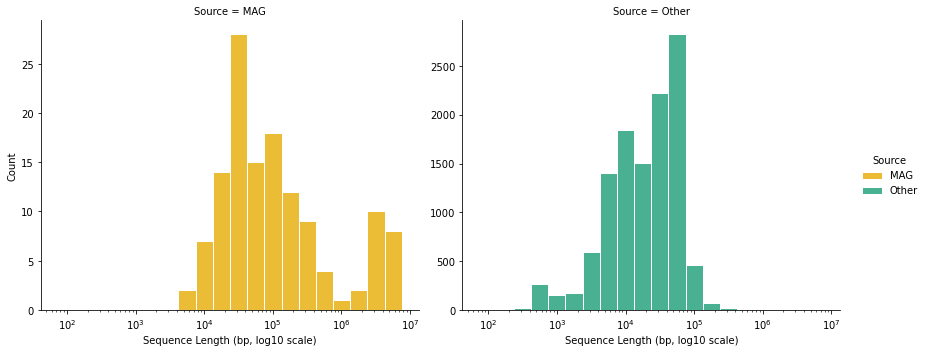

In [11]:
ax=sns.displot(data=df_combined, x='length', col='Source', hue='Source',
                kind="hist", 
                bins=20,          
                palette={'MAG': '#e6ab02', 'Other': '#1b9e77'},
                log_scale=True, 
                facet_kws={'sharey': False}, 
                edgecolor='white',
                alpha=0.8, aspect=1.2)
ax.set_axis_labels("Sequence Length (bp, log10 scale)", "Count")
plt.savefig(r'D:\soil\manuscript\draft\mine\circular_length.svg')

In [17]:
df_combined['Sample'] = df_combined['#seq_name'].str.split('_').str[0]
df_combined

,#seq_name,length,cov.,circ.,repeat,mult.,alt_group,graph_path,MAG,Source,Sample
0,cpsnj01_contig_52172,308050,8,Y,N,1,*,52172,cpsnj01_SemiBin_85,MAG,cpsnj01
1,cpsnj01_contig_80150,30167,6,Y,N,1,*,80150,cpsnj01_SemiBin_30,MAG,cpsnj01
2,cpsnj01_contig_28216,23827,6,Y,N,1,*,28216,cpsnj01_SemiBin_112,MAG,cpsnj01
3,cpsnj02_contig_9516,328497,7,Y,N,1,*,9516,cpsnj02_SemiBin_132,MAG,cpsnj02
4,cpsnj02_contig_75066,126410,11,Y,N,1,*,75066,cpsnj02_SemiBin_1731,MAG,cpsnj02
...,...,...,...,...,...,...,...,...,...,...,...
11544,snj20_contig_4573,2020,4,Y,Y,1,*,4573,NaN,Other,snj20
11545,snj20_contig_67346,1182,29,Y,Y,7,*,67346,NaN,Other,snj20
11546,snj20_contig_314,740,6,Y,Y,1,3078,314,NaN,Other,snj20
11547,snj20_contig_30143,685,5,Y,Y,1,3812,30143,NaN,Other,snj20


In [23]:
sample_counts = df_combined.groupby(['Sample']).size().reset_index()
sample_counts .columns = ['Sample', 'Count'] 
sample_counts

,Sample,Count
0,cpsnj01,91
1,cpsnj02,83
2,cpsnj03,120
3,cpsnj04,100
4,cpsnj08,200
5,cpsnj09,750
6,cpsnj10,516
7,cpsnj11,464
8,cpsnj13,269
9,cpsnj14,269


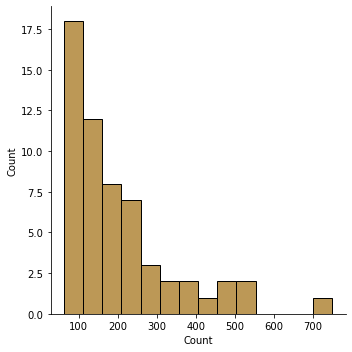

In [24]:
sns.displot(data=sample_counts,
            x='Count',
            color='#a6761d',binwidth=50)

In [12]:
df = pd.read_csv(r'../pre-calculated_data/contig.csv')
df

,Sample,Fragments N50,Circular contigs,Site
0,CPSNJ01,54070,504,NanJing_8
1,CPSNJ02,44941,218,NanJing_8
2,CPSNJ03,41825,381,NanJing_8
3,CPSNJ04,51557,416,NanJing_8
4,CPSNJ08,47353,398,NanJing_8
5,CPSNJ09,63901,116,NanJing_8
6,CPSNJ10,71491,166,NanJing_8
7,CPSNJ11,68347,265,NanJing_8
8,CPSNJ13,62823,122,NanJing_8
9,CPSNJ14,63624,231,NanJing_8


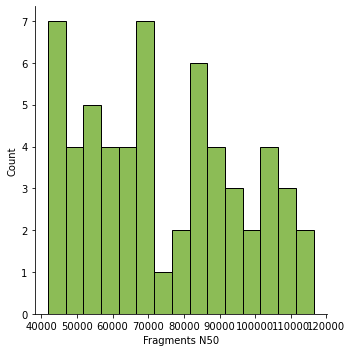

In [16]:
sns.displot(data=df,
            x='Fragments N50',
            color='#66a61e',binwidth=5000)

In [8]:
df = pd.read_csv(r'../pre-calculated_data/checkm_result_report.tsv',sep='\t')
df

,Mag ID,Completeness,Contamination,Polish
0,SemiBin_0,96.90,0.95,flye
1,SemiBin_1,100.00,1.28,flye
2,SemiBin_10,77.98,1.91,flye
3,SemiBin_11,60.89,1.79,flye
4,SemiBin_110,43.54,1.85,flye
...,...,...,...,...
31791,SemiBin_94,63.82,1.38,polypolish
31792,SemiBin_95,67.11,9.06,polypolish
31793,SemiBin_96,48.22,4.17,polypolish
31794,SemiBin_963,64.70,9.76,polypolish


<ipython-input-13-c6a176bbea48>:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.catplot(data=df, x="Polish", y="Completeness",order=order,kind="box",palette=custom_palette)


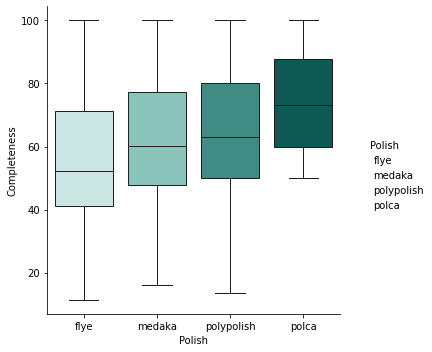

In [13]:
custom_palette = {
    'flye': '#c7eae5',
    'medaka': '#80cdc1',
    'polypolish': '#35978f',
    'polca':'#01665e'
}
order = ['flye','medaka','polypolish','polca']
ax = sns.catplot(data=df, x="Polish", y="Completeness",order=order,kind="box",palette=custom_palette)
plt.savefig(r'D:\soil\manuscript\draft\mine\polish_completeness.svg',bbox_inches='tight')

<ipython-input-14-d62d26eb565a>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.catplot(data=df, x="Polish", y="Contamination",order=order,kind="box",palette=custom_palette)


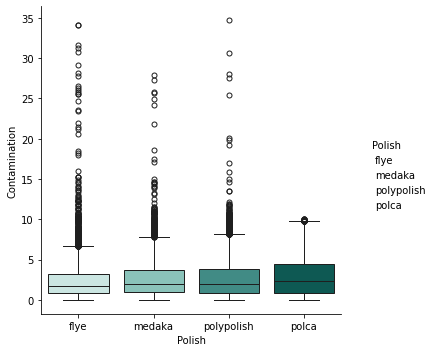

In [14]:
order = ['flye','medaka','polypolish','polca']
ax = sns.catplot(data=df, x="Polish", y="Contamination",order=order,kind="box",palette=custom_palette)
plt.savefig(r'D:\soil\manuscript\draft\mine\polish_contamination.svg',bbox_inches='tight')

In [2]:
def cal(infile):
    circular = 0
    circular_mag = 0
    with open(infile,'rt') as f:
        header = f.readline()
        for line in f:
            parts = line.strip().split('\t')
            if parts[3] == 'Y':
                circular += 1
                if parts[-1] != 'NA':
                    circular_mag += 1
    print(f"Circular contigs: {circular}")
    print(f"Circular contigs with MAG: {circular_mag}")

infile = r'D:\soil\data\assembly_info_mag.tsv'
cal(infile)

Circular contigs: 11679
Circular contigs with MAG: 130
